In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import globals as gl
from Pcm import find_model, calc_normalized_likelihood_in_parcel
import PcmPy as pcm
import pickle
from scipy.stats import ttest_1samp
from matplotlib.patches import ConnectionPatch, Rectangle
from Plot import add_significant_patches_to_ml_rois, add_lineplot_to_boxplot, set_spines_and_ticks_width

plt.style.use('default')

Base directory found: /cifs/diedrichsen/data/SensoriMotorPrediction/
Base directory: /cifs/diedrichsen/data/SensoriMotorPrediction/


P

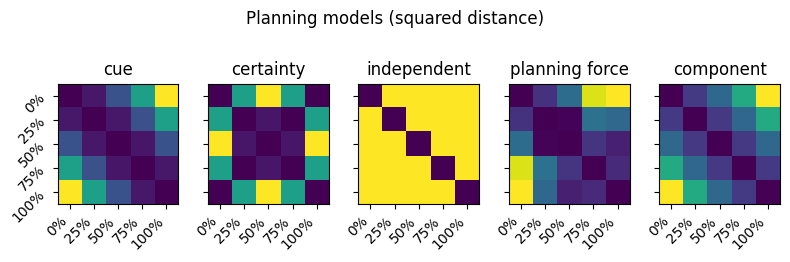

In [2]:
experiment = 'smp2'
glm = 12

f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'M.plan.glm{glm}.pkl'), 'rb')
M = pickle.load(f)

vmin, vmax=-4, 4

D, name = [], []
for m in M:
    if isinstance(m, pcm.FixedModel) & (m.name != 'null'):
        D.append(pcm.G_to_dist(m.G))
        name.append(m.name)
    if isinstance(m, pcm.ComponentModel):
        D.append(pcm.G_to_dist(m.Gc.sum(axis=0)))
        name.append(m.name)

fig, axs = plt.subplots(1, len(D), sharex=True, sharey=True, figsize=(8, 2.5))

for ax, d, n in zip(axs, D, name ):
    # d = np.sign(d) * np.sqrt(np.abs(d))
    ax.imshow(d, )
    ax.set_title(n)

    ax.set_xticks(np.arange(5))
    ax.set_xticklabels(list(gl.regressor_mapping.keys())[:5], rotation=45, ha='right')
    ax.set_yticks(np.arange(5))
    ax.set_yticklabels(list(gl.regressor_mapping.keys())[:5], rotation=45, ha='right')

fig.suptitle('Planning models (squared distance)')
fig.tight_layout()

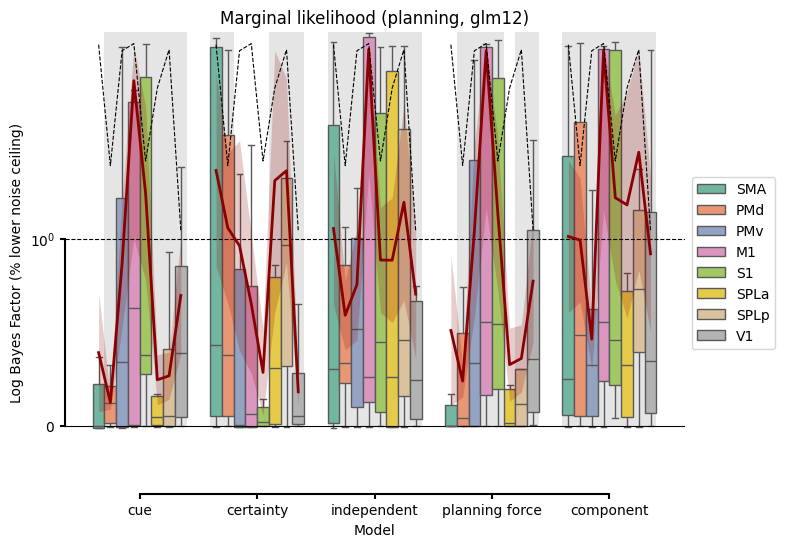

In [3]:
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
glm = 12
Hem = 'L'
experiment = 'smp2'

LL = pd.DataFrame()
for roi in rois:

    T_cv = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T_cv.plan.glm{glm}.{Hem}.{roi}.pkl'))
    T_gr = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T_gr.plan.glm{glm}.{Hem}.{roi}.pkl'))

    LL_tmp = calc_normalized_likelihood_in_parcel(T_cv, T_gr, parcel_field='roi', parcel_name=roi)

    LL = pd.concat([LL, LL_tmp])

LL = LL[
    (LL['model'] == 'cue') |
    (LL['model'] == 'certainty') |
    (LL['model'] == 'planning force') |
    (LL['model'] == 'component') |
    (LL['model'] == 'independent')
]

fig, axs = plt.subplots(figsize=(8, 6))

width = .8
box = sns.boxplot(ax=axs, x='model', y='value', hue='roi', data=LL, showfliers=False, palette='Set2', width=width)

add_significant_patches_to_ml_rois(fig, axs, LL, width, 7)
add_lineplot_to_boxplot(fig, axs, LL, x='model', y='value', hue='roi', box_width=width, lw=2, show_error=True, color='darkred')
add_lineplot_to_boxplot(fig, axs, LL, x='model', y='noise_upper', hue='roi', box_width=width, ls='--', lw=.8)

axs.axhline(0, color='k', ls='-', lw=.8)
axs.axhline(1, color='k', ls='--', lw=.8)

axs.legend(bbox_to_anchor=(1, .5), loc='center left')

axs.set_ylabel('Log Bayes Factor (% lower noise ceiling)')
axs.set_xlabel('Model')
axs.set_yscale('symlog',linscale=10)

axs.spines[['top', 'right',]].set_visible(False)
axs.spines[['bottom',]].set_bounds(0, 4)
axs.spines[['left',]].set_bounds(0, 1)
set_spines_and_ticks_width(axs, spine_width=1.5,spine_sides=('left', 'bottom',), tick_width=1.5,axes=('x', 'y'),which='both')

axs.set_title(f'Marginal likelihood (planning, glm{glm})')
plt.show()

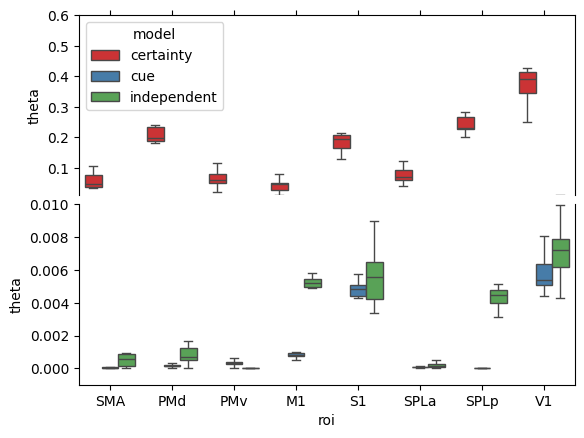

In [30]:
# fig, axs = plt.subplots(1, 2, width_ratios=(2, 1.5),figsize=(8, 4))

legend_handles, legend_labels = None, None  # To store legend info

M, idx = find_model(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'M.plan.glm{glm}.pkl'), 'component')
n_param = M.n_param
components = ['cue','certainty', 'independent']

theta = {
    'sn': [],
    'roi': [],
    'model': [],
    'theta': []
}
for roi in rois:

    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_cv.plan.glm{glm}.{Hem}.{roi}.pkl'), "rb")
    theta_tmp = pickle.load(f)[idx][:n_param]

    theta['theta'].extend(np.exp(theta_tmp.flatten()))
    theta['sn'].extend(np.tile(np.arange(theta_tmp.shape[1]), M.n_param))
    theta['roi'].extend([roi] * n_param * theta_tmp.shape[1])
    theta['model'].extend([mdl for mdl in components for _ in range(theta_tmp.shape[1])])

    # _, pval = ttest_1samp(np.exp(theta_tmp).T, popmean=0)
    #
    # pval_series = pd.Series(pval, index=[
    #     'cue',
    #     'certainty',
    #     'independent',
    # ])
    #
    # # Print formatted p-values
    # print(f"P-values {roi}:")
    # print(pval_series.to_string(float_format="%.10f"))
    # print('\t')

theta = pd.DataFrame(theta)

fig, axs = plt.subplots(2, 1, sharex=True)
fig.subplots_adjust(hspace=0.05)

sns.boxplot(ax=axs[0], data=theta, x='roi', y='theta', hue='model', showfliers=False, palette='Set1', hue_order=['certainty','cue',  'independent'])
sns.boxplot(ax=axs[1], data=theta, x='roi', y='theta', hue='model', showfliers=False, palette='Set1', legend=False, hue_order=['certainty','cue', 'independent'])

axs[0].set_ylim(.01, .6)  # outliers only
axs[1].set_ylim(-.001, .01)  # most of the data

# hide the spines between ax and ax2
axs[0].spines.bottom.set_visible(False)
axs[1].spines.top.set_visible(False)
axs[0].xaxis.tick_top()
axs[0].tick_params(labeltop=False)  # don't put tick labels at the top
axs[1].xaxis.tick_bottom()

# d = .5  # proportion of vertical to horizontal extent of the slanted line
# kwargs = dict(marker=[(-1, -d), (1, d)], markersize=12,
#               linestyle="none", color='k', mec='k', mew=1, clip_on=False)
# axs[0].plot([0, 1], [0, 0], transform=axs[0].transAxes, **kwargs)
# axs[1].plot([0, 1], [1, 1], transform=axs[1].transAxes, **kwargs)

plt.show()

noise upper: 229.35, noise lower: 208.02
noise upper: 498.52, noise lower: 434.27
noise upper: 188.46, noise lower: 156.45
noise upper: 545.01, noise lower: 505.93
noise upper: 1505.86, noise lower: 1402.64
noise upper: 373.85, noise lower: 321.89
noise upper: 480.29, noise lower: 433.70
noise upper: 783.62, noise lower: 617.72
SMA, finger - pval vs. 0: 0.06, pval vs. 1: 0.00
PMd, finger - pval vs. 0: 0.06, pval vs. 1: 0.00


NameError: name 'patches' is not defined

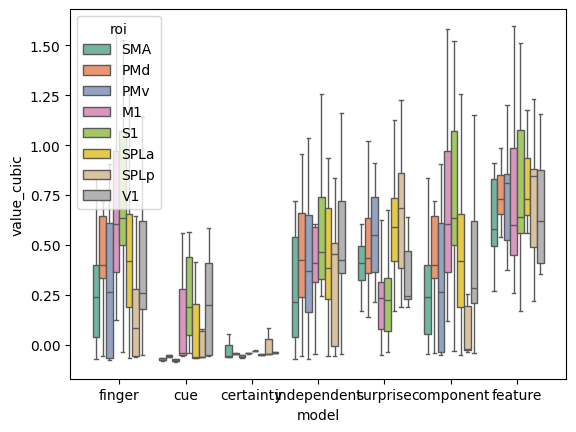

In [5]:
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
glm = 12
Hem = 'L'
experiment = 'smp2'

LL = pd.DataFrame()
for roi in rois:

    T_cv = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T_cv.exec.glm{glm}.{Hem}.{roi}.pkl'))
    T_gr = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T_gr.exec.glm{glm}.{Hem}.{roi}.pkl'))

    likelihood = T_cv.likelihood
    baseline = likelihood.loc[:,'null'].values
    likelihood = likelihood - baseline.reshape(-1,1)

    noise_upper = (T_gr.likelihood['ceil'] - baseline).mean()

    noise_lower_abs = likelihood.ceil.mean()

    assert noise_upper > noise_lower_abs
    print(f'noise upper: {noise_upper:.2f}, noise lower: {noise_lower_abs:.2f}')

    likelihood = likelihood / noise_lower_abs
    noise_upper = noise_upper / noise_lower_abs

    noise_lower = likelihood.ceil.mean()

    LL_tmp = pd.melt(likelihood)
    LL_tmp['roi'] = roi
    LL_tmp['noise_lower'] = noise_lower
    LL_tmp['noise_upper'] = noise_upper

    LL = pd.concat([LL, LL_tmp])

LL = LL[
    (LL['model'] == 'cue') |
    (LL['model'] == 'finger') |
    (LL['model'] == 'certainty') |
    (LL['model'] == 'surprise') |
    (LL['model'] == 'independent') |
    (LL['model'] == 'component') |
    (LL['model'] == 'feature')
]

fig, axs = plt.subplots()

LL['value_cubic'] = np.sign(LL['value']) * np.cbrt(np.abs(LL['value']))

sns.boxplot(ax=axs, x='model', y='value_cubic', hue='roi', data=LL, showfliers=False, palette='Set2', width=.8)

for m, md in enumerate(LL.model.unique()):
    for r, roi in enumerate(LL.roi.unique()):
        LL_tmp = LL[(LL['model'] == md) & (LL['roi'] == roi)]
        _, pval0 = ttest_1samp(LL_tmp['value'], popmean=0, alternative='greater')
        _, pval1 = ttest_1samp(LL_tmp['value'], popmean=1, alternative='less')
        if pval0 < .05:
            xInt = (m - .4 + r * .1, m - .4 + r * .1 + .1,)
            axs.hlines(1.4, xInt[0], xInt[1], color='darkgrey')
            rect = patches.Rectangle(
                        (xInt[0], 0),              # bottom-left corner (x, y)
                        xInt[1] - xInt[0],         # width
                        1.4,                       # height
                        fc='grey',
                        alpha=0.2,
                        lw=0
                    )
            axs.add_patch(rect)
        print(f'{roi}, {md} - pval vs. 0: {pval0:.2f}, pval vs. 1: {pval1:.2f}')

axs.axhline(0, color='k', ls='-', lw=.8)
axs.axhline(1, color='k', ls='--', lw=.8)

axs.legend(bbox_to_anchor=(1, .5), loc='center left')

axs.set_ylabel('Log Bayes Factor (% lower noise ceiling)')
axs.set_xlabel('Model')

axs.set_xticks(axs.get_xticks())
axs.set_xticklabels(axs.get_xticklabels(), rotation=45)

axs.set_title('Marginal likelihood (execution)')
plt.show()